# ASL Dynamic Signs — Transformer v2

Baseado no v1 (funcionou com 75% acc a 50 classes).

**Melhorias sobre v1:**
- `nhead=4` (64 dim/head vs 32), `dim_feedforward=1024` (4× d_model vs 2×), 6 camadas
- Speed perturbation (50% prob) no augmentation
- Early stopping com patience
- Optimizer + scheduler reinicializados no início de cada run


In [11]:
# Garante dependências críticas antes de qualquer import
import importlib, subprocess, sys

def ensure(pkg, import_name=None):
    import_name = import_name or pkg
    if importlib.util.find_spec(import_name) is None:
        print(f'A instalar {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'{pkg} instalado. Reinicia o kernel se obtiveres ImportError abaixo.')
    else:
        print(f'{pkg} OK')

ensure('pyarrow')
ensure('fastparquet')  # fallback para pd.read_parquet


pyarrow OK
fastparquet OK


## 1. Imports

In [12]:
import os, json, math, random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Configuração

In [13]:
# --- Caminhos (iguais ao v1) ---
DATA_DIR     = Path('/home/luiscunha/Downloads/asl-signs')
LANDMARK_DIR = DATA_DIR / 'train_landmark_files'
TRAIN_CSV    = DATA_DIR / 'train.csv'

# --- Landmarks (igual ao v1) ---
USE_TYPES = ['left_hand', 'right_hand', 'pose']

# --- Número de classes ---
NUM_CLASSES_TO_USE = 50   

# --- Hiperparâmetros (iguais ao v1) ---
MAX_FRAMES    = 64
BATCH_SIZE    = 64
NUM_EPOCHS    = 80
LR            = 3e-4
WEIGHT_DECAY  = 5e-4
WARMUP_EPOCHS = 5     # 2 épocas: LR atinge max mais cedo que os 5 do v1
VAL_SPLIT     = 0.1
PATIENCE      = 10

# --- Arquitectura v2 (melhorada) ---
D_MODEL        = 256
NHEAD          = 4    # v1 usava 8 → dim/head era 32; agora 64 (standard)
NUM_LAYERS     = 4    # v1 usava 4
DIM_FEEDFORWARD= 512 # v1 usava 512 → ratio 2x; agora 4x (standard)
DROPOUT        = 0.25

print('OK — configuração carregada.')

OK — configuração carregada.


## 3. Dados

In [14]:
train_df = pd.read_csv(TRAIN_CSV)
print(f'Total: {len(train_df)} sequências, {train_df["sign"].nunique()} sinais únicos')

# Selecionar classes — IGUAL AO v1: ordem de aparição no CSV (não sorted)
selected_signs = list(train_df['sign'].unique()[:NUM_CLASSES_TO_USE])

train_df = train_df[train_df['sign'].isin(selected_signs)].reset_index(drop=True)

# sign2idx na mesma ordem que v1 (ordem de aparição, não sorted)
sign2idx = {sign: i for i, sign in enumerate(selected_signs)}
idx2sign = {i: sign for sign, i in sign2idx.items()}
NUM_CLASSES = len(sign2idx)

print(f'Classes: {NUM_CLASSES} | Sequências: {len(train_df)}')
print(f'Média por classe: {len(train_df)/NUM_CLASSES:.0f}')

Total: 94477 sequências, 250 sinais únicos
Classes: 50 | Sequências: 18808
Média por classe: 376


## 4. Pré-processamento (idêntico ao v1)

In [15]:
def load_landmarks(part_id, seq_id, landmark_dir, use_types, max_frames):
    path = landmark_dir / f'{part_id}' / f'{seq_id}.parquet'
    expected_dim = 225
    try:
        df = pd.read_parquet(path)
        df = df[df['type'].isin(use_types)]
        if df.empty:
            return np.zeros((max_frames, expected_dim), dtype=np.float32), 0
        pivot = df.pivot(index='frame', columns=['type', 'landmark_index'], values=['x', 'y', 'z'])
        pivot = pivot.reorder_levels([1, 2, 0], axis=1).sort_index(axis=1)
        arr = pivot.values.astype(np.float32)
        arr = np.nan_to_num(arr, nan=0.0)
        actual_len = len(arr)
    except Exception as e:
        # Mostrar os primeiros erros para facilitar diagnóstico futuro
        if not hasattr(load_landmarks, '_err_count'):
            load_landmarks._err_count = 0
        load_landmarks._err_count += 1
        if load_landmarks._err_count <= 3:
            print(f'[WARN] load_landmarks erro #{load_landmarks._err_count}: {type(e).__name__}: {e}')
        return np.zeros((max_frames, expected_dim), dtype=np.float32), 0

    # Normalização (igual ao v1)
    nonzero = arr[arr != 0]
    if len(nonzero) > 0:
        arr[:, 0::3] -= arr[:, 0::3][arr[:, 0::3] != 0].mean()
        arr[:, 1::3] -= arr[:, 1::3][arr[:, 1::3] != 0].mean()

    T, F = arr.shape
    if T < max_frames:
        arr = np.concatenate([arr, np.zeros((max_frames - T, F), dtype=np.float32)], axis=0)
    else:
        arr = arr[:max_frames]
        actual_len = max_frames
    return arr, actual_len

# Verificar INPUT_DIM
_r = train_df.iloc[0]
_s, _l = load_landmarks(_r['participant_id'], _r['sequence_id'], LANDMARK_DIR, USE_TYPES, MAX_FRAMES)
INPUT_DIM = _s.shape[1]
print(f'INPUT_DIM: {INPUT_DIM}  |  real_len exemplo: {_l}')
assert _l > 0, 'ERRO: real_len=0 — verificar pyarrow (pip install pyarrow) e LANDMARK_DIR'
print('✓ Dados a carregar correctamente')

INPUT_DIM: 225  |  real_len exemplo: 23
✓ Dados a carregar correctamente


## 5. Dataset (igual ao v1 + speed perturbation com 50% prob)

In [16]:
class ASLDataset(Dataset):
    def __init__(self, df, landmark_dir, sign2idx, use_types, max_frames, augment=False):
        self.df           = df.reset_index(drop=True)
        self.landmark_dir = Path(landmark_dir)
        self.sign2idx     = sign2idx
        self.use_types    = use_types
        self.max_frames   = max_frames
        self.augment      = augment

    def __len__(self):
        return len(self.df)

    def _speed_perturb(self, arr: np.ndarray, real_len: int):
        """Resampla ±25% da velocidade. Retorna (arr_novo, novo_real_len)."""
        if real_len < 4:
            return arr, real_len
        speed   = random.uniform(0.8, 1.25)
        new_len = max(4, min(int(real_len * speed), self.max_frames))
        indices = np.linspace(0, real_len - 1, new_len).astype(int)
        new_arr = np.zeros_like(arr)
        new_arr[:new_len] = arr[indices]
        return new_arr, new_len

    def _augment(self, x: torch.Tensor, real_len: int) -> torch.Tensor:
        # Igual ao v1
        if random.random() < 0.5:                     # flip horizontal
            x = x.clone(); x[:, 0::3] *= -1
        if random.random() < 0.5:                     # ruído gaussiano
            x = x + torch.randn_like(x) * 0.01
        if random.random() < 0.3 and real_len > 4:    # time masking
            mask_len   = random.randint(1, max(1, real_len // 4))
            mask_start = random.randint(0, real_len - mask_len)
            x[mask_start:mask_start + mask_len] = 0.0
        if random.random() < 0.3:                     # feature masking
            n = x.shape[1]
            k = random.randint(1, max(1, n // 8))
            x[:, random.sample(range(n), k)] = 0.0
        return x

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr, real_len = load_landmarks(
            row['participant_id'], row['sequence_id'],
            self.landmark_dir, self.use_types, self.max_frames
        )

        # Speed perturbation ANTES de converter para tensor (50% prob, só no treino)
        if self.augment and random.random() < 0.5:
            arr, real_len = self._speed_perturb(arr, real_len)

        x = torch.tensor(arr, dtype=torch.float32)
        y = self.sign2idx[row['sign']]

        if self.augment:
            x = self._augment(x, real_len)

        pad_mask = torch.zeros(self.max_frames, dtype=torch.bool)
        pad_mask[real_len:] = True

        return x, torch.tensor(y, dtype=torch.long), pad_mask

In [17]:
train_split, val_split = train_test_split(
    train_df, test_size=VAL_SPLIT, stratify=train_df['sign'], random_state=SEED
)
print(f'Treino: {len(train_split)} | Validação: {len(val_split)}')

train_ds = ASLDataset(train_split, LANDMARK_DIR, sign2idx, USE_TYPES, MAX_FRAMES, augment=True)
val_ds   = ASLDataset(val_split,   LANDMARK_DIR, sign2idx, USE_TYPES, MAX_FRAMES, augment=False)

# num_workers=4 igual ao v1; se der erro de multiprocessing, mudar para 0
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
print(f'Batches treino: {len(train_loader)} | val: {len(val_loader)}')

Treino: 16927 | Validação: 1881
Batches treino: 265 | val: 30


## 6. Modelo Transformer v2

In [18]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        # Igual ao v1: register_buffer sem unsqueeze extra na posição 0
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class ASLTransformerModel(nn.Module):
    """Igual ao v1 mas com arquitectura corrigida (nhead=4, ffn=1024, 6 camadas)."""
    def __init__(self, input_dim, num_classes,
                 d_model=256, nhead=4, num_layers=6,
                 dim_feedforward=1024, dropout=0.1, max_len=512):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model)
        )
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            activation='gelu', batch_first=True,
            norm_first=True,   # Pre-LN: igual ao v1
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers, norm=nn.LayerNorm(d_model)
        )
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x, pad_mask=None):
        B, T, _ = x.shape
        x   = self.pos_enc(self.input_proj(x))
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)            # (B, T+1, d_model)
        if pad_mask is not None:
            cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            pad_mask = torch.cat([cls_mask, pad_mask], dim=1)
        x = self.transformer(x, src_key_padding_mask=pad_mask)
        return self.classifier(x[:, 0])


model = ASLTransformerModel(
    input_dim=INPUT_DIM, num_classes=NUM_CLASSES,
    d_model=D_MODEL, nhead=NHEAD, num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD, dropout=DROPOUT
).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros treináveis: {total_params:,}')
print(model)

Parâmetros treináveis: 2,246,194
ASLTransformerModel(
  (input_proj): Sequential(
    (0): Linear(in_features=225, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.25, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.25, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.25, inplace=False)
        (dropout2): Dropout(p=0.25, inplace=False)
      )
    

## 7. Treino

In [19]:
def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = total_correct = total = 0
    for x, y, mask in tqdm(loader, desc='Treino', leave=False):
        x, y, mask = x.to(device), y.to(device), mask.to(device)
        optimizer.zero_grad()
        logits = model(x, pad_mask=mask)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()   # step por batch — igual ao v1
        preds          = logits.argmax(dim=-1)
        total_loss    += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total         += x.size(0)
    return total_loss / total, total_correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = total_correct = total = 0
    for x, y, mask in tqdm(loader, desc='Val', leave=False):
        x, y, mask = x.to(device), y.to(device), mask.to(device)
        logits = model(x, pad_mask=mask)
        loss   = criterion(logits, y)
        preds          = logits.argmax(dim=-1)
        total_loss    += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total         += x.size(0)
    return total_loss / total, total_correct / total


@torch.no_grad()
def top5_accuracy(model, loader, device):
    model.eval()
    correct = total = 0
    for x, y, mask in loader:
        x, y, mask = x.to(device), y.to(device), mask.to(device)
        top5 = model(x, pad_mask=mask).topk(5, dim=-1).indices
        correct += (top5 == y.unsqueeze(1)).any(dim=1).sum().item()
        total   += y.size(0)
    return correct / total

In [20]:
# ── Reinicializar optimizer e scheduler de raiz ──────────────────────────
# (garante que re-executar esta célula não herda estado de um run anterior)
criterion = nn.CrossEntropyLoss(label_smoothing=0.15)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def get_scheduler(opt, warmup_epochs, total_epochs, steps_per_epoch):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps  = total_epochs  * steps_per_epoch
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return optim.lr_scheduler.LambdaLR(opt, lr_lambda)

scheduler = get_scheduler(optimizer, WARMUP_EPOCHS, NUM_EPOCHS, len(train_loader))
print(f'Steps/época: {len(train_loader)} | Warmup: {WARMUP_EPOCHS} épocas | LR max: {LR:.1e}')

# ── Loop principal ─────────────────────────────────────────────────────────
best_val_acc    = 0.0
best_path       = 'asl_transformer_v2_50_2_best.pt'
patience_count  = 0
history         = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler, DEVICE)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion, DEVICE)
    current_lr = optimizer.param_groups[0]['lr']

    for k, v in zip(['train_loss','train_acc','val_loss','val_acc','lr'],
                    [tr_loss, tr_acc, vl_loss, vl_acc, current_lr]):
        history[k].append(v)

    saved = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_path)
        saved = ' ✓ saved'; patience_count = 0
    else:
        patience_count += 1

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train {tr_loss:.4f}/{tr_acc:.4f} | '
          f'Val {vl_loss:.4f}/{vl_acc:.4f} | '
          f'LR {current_lr:.2e}{saved}')

    if patience_count >= PATIENCE:
        print(f'Early stopping (sem melhoria há {PATIENCE} épocas).'); break

print(f'\nMelhor Val Acc: {best_val_acc:.4f}')

Steps/época: 265 | Warmup: 5 épocas | LR max: 3.0e-04


Treino:   0%|          | 0/265 [00:00<?, ?it/s]

Val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 01/80 | Train 3.9210/0.0214 | Val 3.9032/0.0314 | LR 6.00e-05 ✓ saved


Treino:   0%|          | 0/265 [00:00<?, ?it/s]

...

Val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 79/80 | Train 1.6749/0.7748 | Val 1.7317/0.7602 | LR 1.32e-07


Treino:   0%|          | 0/265 [00:00<?, ?it/s]

Val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 80/80 | Train 1.6823/0.7697 | Val 1.7317/0.7597 | LR 0.00e+00

Melhor Val Acc: 0.7634


## 8. Avaliação & Exportação

Val:   0%|          | 0/30 [00:00<?, ?it/s]

Top-1: 0.7634 | Top-5: 0.9006


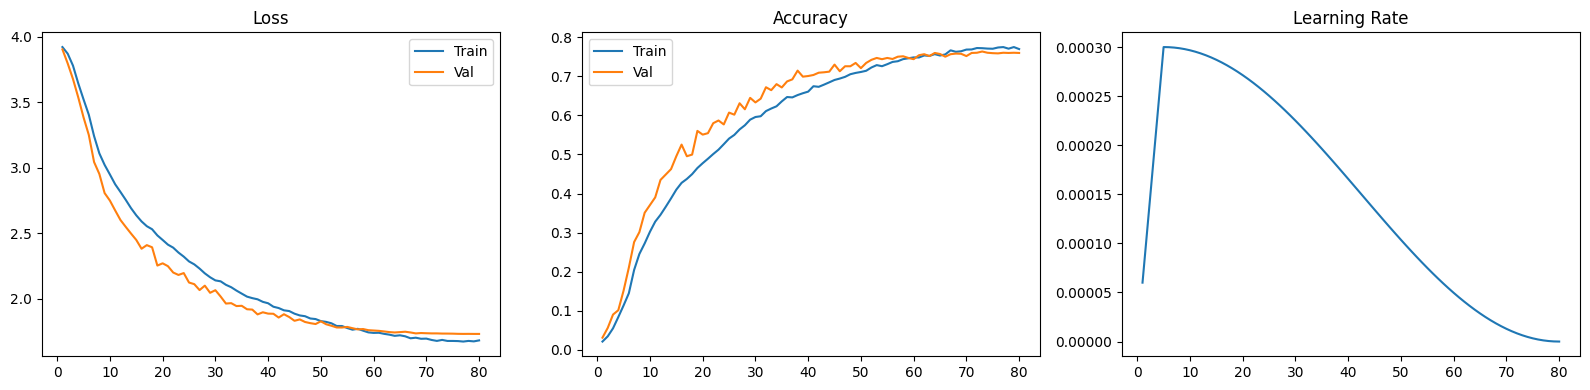

In [21]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
_, final_val_acc = eval_epoch(model, val_loader, criterion, DEVICE)
top5_acc         = top5_accuracy(model, val_loader, DEVICE)
print(f'Top-1: {final_val_acc:.4f} | Top-5: {top5_acc:.4f}')

# Curvas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ep = range(1, len(history['train_acc'])+1)
axes[0].plot(ep, history['train_loss'], label='Train'); axes[0].plot(ep, history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(ep, history['train_acc'], label='Train'); axes[1].plot(ep, history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()
axes[2].plot(ep, history['lr']); axes[2].set_title('Learning Rate')
plt.tight_layout(); plt.savefig('transformer_v2_curves.png', dpi=150); plt.show()

In [22]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
# Avaliação detalhada com o melhor modelo
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, y, mask in tqdm(val_loader, desc='Avaliação final'):
        x, mask = x.to(DEVICE), mask.to(DEVICE)
        logits  = model(x, pad_mask=mask)
        probs   = F.softmax(logits, dim=-1)
        preds   = logits.argmax(dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(y.tolist())
        all_probs.extend(probs.cpu().tolist())
final_acc = accuracy_score(all_labels, all_preds)
print(f'Accuracy final (melhor modelo): {final_acc:.4f}')
# Top-5 accuracy
probs_tensor = torch.tensor(all_probs)
labels_tensor = torch.tensor(all_labels)
top5 = probs_tensor.topk(5, dim=1).indices
top5_acc = (top5 == labels_tensor.unsqueeze(1)).any(dim=1).float().mean().item()
print(f'Top-5 Accuracy: {top5_acc:.4f}')

Avaliação final:   0%|          | 0/30 [00:00<?, ?it/s]

Accuracy final (melhor modelo): 0.7634
Top-5 Accuracy: 0.9006


In [23]:
report = classification_report(
    all_labels, all_preds,
    target_names=[idx2sign[i] for i in range(NUM_CLASSES)],
    output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:-3]
print('10 sinais com menor F1:')
print(report_df.sort_values('f1-score').head(10)[['precision', 'recall', 'f1-score', 'support']].to_string())
print('\n10 sinais com maior F1:')
print(report_df.sort_values('f1-score', ascending=False).head(10)[['precision', 'recall', 'f1-score', 'support']].to_string())

10 sinais com menor F1:
        precision    recall  f1-score  support
finger   0.473684  0.473684  0.473684     38.0
owie     0.580645  0.500000  0.537313     36.0
puzzle   0.588235  0.588235  0.588235     34.0
vacuum   0.575758  0.612903  0.593750     31.0
fall     0.760000  0.500000  0.603175     38.0
there    0.666667  0.555556  0.606061     36.0
go       0.666667  0.564103  0.611111     39.0
cheek    0.600000  0.648649  0.623377     37.0
empty    0.740741  0.540541  0.625000     37.0
drawer   0.696970  0.621622  0.657143     37.0

10 sinais com maior F1:
             precision    recall  f1-score  support
see           0.900000  0.923077  0.911392     39.0
wake          0.945946  0.875000  0.909091     40.0
flower        0.900000  0.900000  0.900000     40.0
apple         0.871795  0.894737  0.883117     38.0
bird          0.875000  0.875000  0.875000     40.0
clown         0.853659  0.897436  0.875000     39.0
frenchfries   0.967742  0.789474  0.869565     38.0
have          0.87

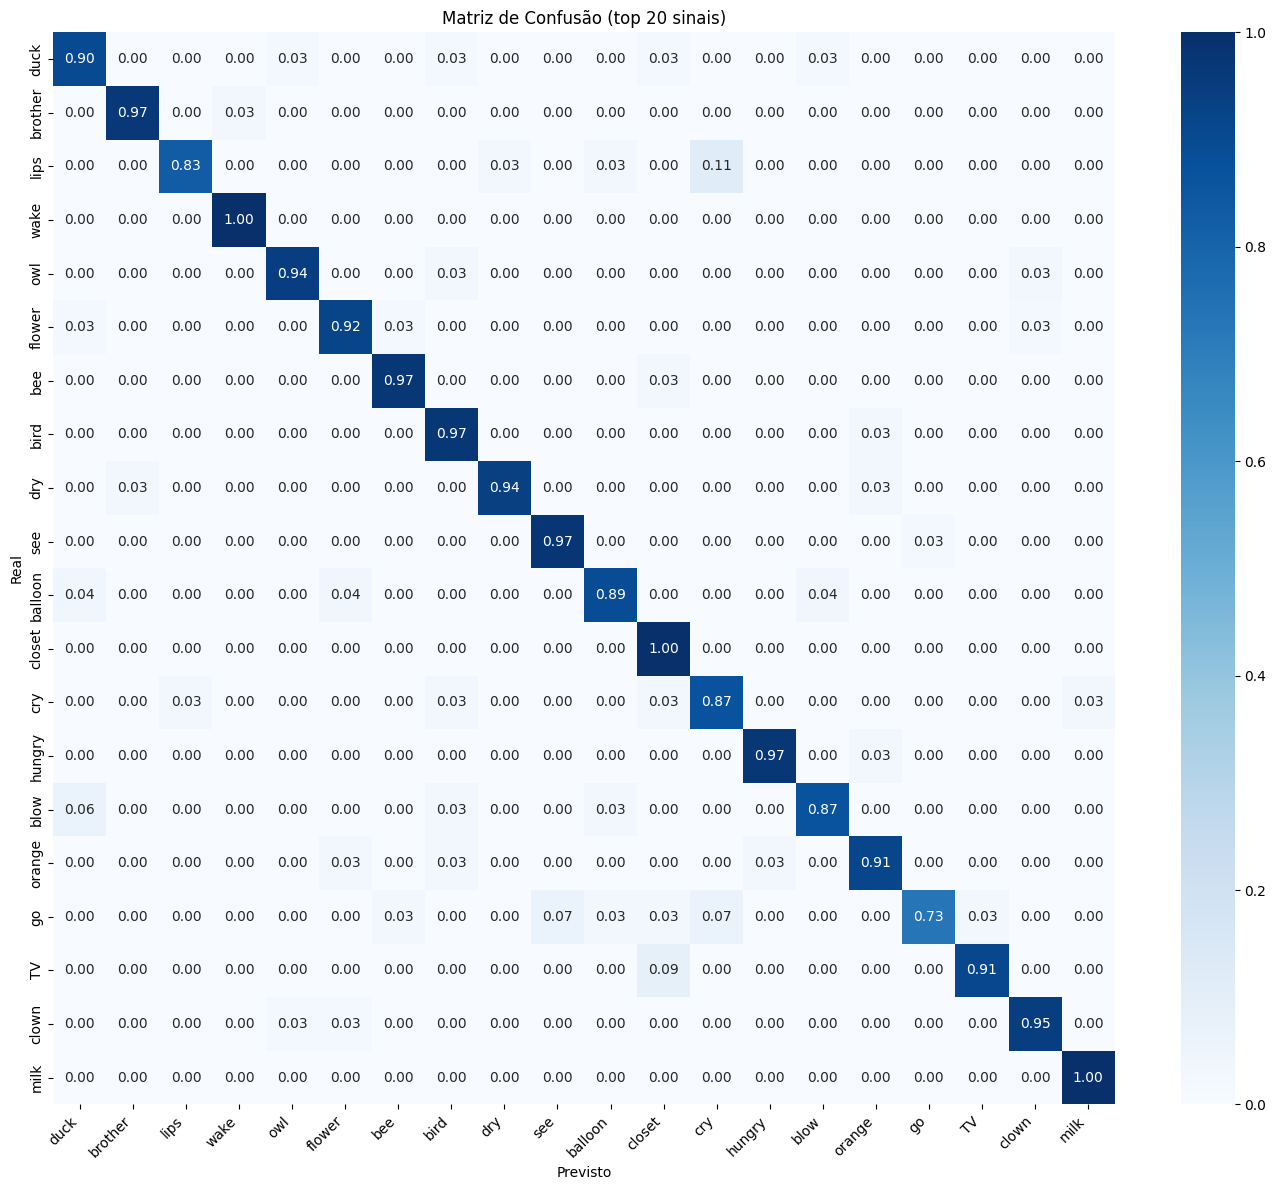

In [24]:
top20_signs = report_df.sort_values('support', ascending=False).head(20).index.tolist()
top20_idx   = [sign2idx[s] for s in top20_signs]
mask_top20  = [l in top20_idx for l in all_labels]
labels_20   = [all_labels[i] for i in range(len(all_labels)) if mask_top20[i]]
preds_20    = [all_preds[i]  for i in range(len(all_preds))  if mask_top20[i]]
cm = confusion_matrix(labels_20, preds_20, labels=top20_idx)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top20_signs, yticklabels=top20_signs)
plt.title('Matriz de Confusão (top 20 sinais)')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('transformer_v2_confusion_matrix.png', dpi=150)
plt.show()

In [25]:
OUTPUT = Path('/home/luiscunha/ASLAI--SA/TrabalhoPraticoNovo/shared_models/asl_transformer_v2_50_2.pt')
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'sign2idx': sign2idx, 'idx2sign': idx2sign,
    'input_dim': INPUT_DIM, 'num_classes': NUM_CLASSES,
    'max_frames': MAX_FRAMES, 'use_types': USE_TYPES,
    'val_acc': final_acc, 'top5_acc': top5_acc,
    'model_config': dict(d_model=D_MODEL, nhead=NHEAD, num_layers=NUM_LAYERS,
                         dim_feedforward=DIM_FEEDFORWARD, dropout=DROPOUT),
}, OUTPUT)
print(f'Guardado em {OUTPUT}')
print(f'Classes: {NUM_CLASSES} | Top-1: {final_acc:.4f} | Top-5: {top5_acc:.4f}')

Guardado em /home/luiscunha/ASLAI--SA/TrabalhoPraticoNovo/shared_models/asl_transformer_v2_50_2.pt
Classes: 50 | Top-1: 0.7634 | Top-5: 0.9006


In [26]:
import torch.nn.functional as F

def predict_sign(part_id, seq_id, model, landmark_dir, use_types, max_frames, idx2sign, device):
    """Faz previsão para uma sequência e devolve top-5 sinais com probabilidades."""
    model.eval()

    arr, real_len = load_landmarks(part_id, seq_id, landmark_dir, use_types, max_frames)
    x        = torch.tensor(arr, dtype=torch.float32).unsqueeze(0).to(device)  # (1, T, F)
    pad_mask = torch.zeros(1, max_frames, dtype=torch.bool).to(device)
    pad_mask[0, real_len:] = True

    with torch.no_grad():
        logits = model(x, pad_mask=pad_mask)
        probs  = F.softmax(logits, dim=-1).squeeze(0)

    top5_probs, top5_idx = probs.topk(5)
    results = [(idx2sign[i.item()], p.item()) for i, p in zip(top5_idx, top5_probs)]
    return results


# Testar numa sequência aleatória da validação
test_row  = val_split.sample(1).iloc[0]
true_sign = test_row['sign']
part_id   = test_row['participant_id']
seq_id    = test_row['sequence_id']

predictions = predict_sign(part_id, seq_id, model, LANDMARK_DIR, USE_TYPES, MAX_FRAMES, idx2sign, DEVICE)

print(f'Sinal real: {true_sign}')
print(f'\nTop-5 previsões:')
for sign, prob in predictions:
    marker = ' ← CORRETO' if sign == true_sign else ''
    print(f'  {sign:<20} {prob:.4f}{marker}')


Sinal real: closet

Top-5 previsões:
  closet               0.8136 ← CORRETO
  wake                 0.0423
  there                0.0131
  mitten               0.0129
  go                   0.0118
